# SPARTAN benchmark run: Human Colon Cancer Visium HD, K=14

This is a fixed-parameter production run for the spatial-domain benchmark.

- Full `manual_analysis_count_area_filtered` table; no smoke subset.
- 2,000 HVGs selected using the supervisor-specified Scanpy call.
- Supervisor-confirmed SPARTAN Visium HD graph: `grid`, 6 spatial neighbours, 2 rings.
- Fixed Leiden resolution `0.66484375` and seed 1, calibrated to K=14.
- No resolution search, SVG analysis, H5AD export, or Zarr writing.
- Produces domain labels, spatial-domain figure, compact benchmark metrics, marker-domain validation, runtime, memory, and metadata.

## 1. Environment

Use the dedicated kernel `Python 3.11_SPARTAN`.

```bash
conda activate python3.11_SPARTAN
```

In [1]:
%load_ext autotime

time: 23.9 μs (started: 2026-08-26 00:15:22 +01:00)


In [2]:
import json
import os
import platform
import sys
import time
from contextlib import contextmanager
from pathlib import Path

os.environ["MPLCONFIGDIR"] = "/private/tmp/mplconfig"
os.environ["NUMBA_CACHE_DIR"] = "/private/tmp/numba_cache"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata as sd
import spartan as sp
from scipy import sparse

try:
    import psutil
except ImportError:
    psutil = None

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False)
step_times = []


def current_memory_gb():
    if psutil is None:
        return np.nan
    return psutil.Process(os.getpid()).memory_info().rss / 1024**3


@contextmanager
def record_step(step_name):
    start = time.perf_counter()
    memory_start = current_memory_gb()
    try:
        yield
    finally:
        seconds = time.perf_counter() - start
        memory_end = current_memory_gb()
        row = {
            "step": step_name,
            "seconds": seconds,
            "minutes": seconds / 60,
            "memory_start_gb": memory_start,
            "memory_end_gb": memory_end,
            "memory_delta_gb": memory_end - memory_start,
        }
        step_times.append(row)
        print(
            f"{step_name}: {seconds / 60:.2f} min; "
            f"RSS {memory_end:.2f} GB; delta {memory_end - memory_start:+.2f} GB"
        )


print("Python:", sys.version)
print("Platform:", platform.platform())
print("SPARTAN:", getattr(sp, "__version__", "unknown"))
print("Scanpy:", sc.__version__)
print("SpatialData:", sd.__version__)

Matplotlib is building the font cache; this may take a moment.
/Users/zhuzhengyang/anaconda3/envs/python3.11_SPARTAN/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.11.13 (main, Jun  5 2025, 08:14:07) [Clang 14.0.6 ]
Platform: macOS-10.16-x86_64-i386-64bit
SPARTAN: 0.2.0
Scanpy: 1.11.5
SpatialData: 0.7.3
time: 14.4 s (started: 2026-08-26 00:15:22 +01:00)


/Users/zhuzhengyang/anaconda3/envs/python3.11_SPARTAN/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/Users/zhuzhengyang/anaconda3/envs/python3.11_SPARTAN/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/var/folders/7g/htgw64550j563bz1jw9wby_80000gn/T/ipykernel_1213/1366418114.py:63: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)


## 2. Fixed benchmark configuration

In [3]:
DATA_DIR = Path("/Users/zhuzhengyang/Desktop/HDS_Dissertation/Human_Colon_Cancer_Visium_HD")
SDATA_PATH = DATA_DIR / "Visium_HD_Human_Colon_Cancer_processed_clusters"
TABLE_KEY = "manual_analysis_count_area_filtered"
OUT_DIR = DATA_DIR / "spartan_benchmark_outputs" / "K14"

TARGET_K = 14
N_TOP_GENES = 2000
SEED = 1
FIXED_RESOLUTION = 0.66484375

SPARTAN_PARAMS = dict(
    spatial_coord="grid",
    spatial_neighborhood="knn",
    spatial_neighs=6,
    spatial_rings=2,
    total_pca_comps=50,
    pca_comps_extract=30,
    gene_coord="generic",
    gene_neighs=15,
    alpha=0.80,
    beta1=0.10,
    beta2=0.40,
    resolution=FIXED_RESOLUTION,
    seed=SEED,
    key_added="spartan_domains",
    copy=True,
)

OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Target K:", TARGET_K)
print("Fixed resolution:", FIXED_RESOLUTION)
print("Output directory:", OUT_DIR)
print("SPARTAN parameters:", SPARTAN_PARAMS)

Target K: 14
Fixed resolution: 0.66484375
Output directory: /Users/zhuzhengyang/Desktop/HDS_Dissertation/Human_Colon_Cancer_Visium_HD/spartan_benchmark_outputs/K14
SPARTAN parameters: {'spatial_coord': 'grid', 'spatial_neighborhood': 'knn', 'spatial_neighs': 6, 'spatial_rings': 2, 'total_pca_comps': 50, 'pca_comps_extract': 30, 'gene_coord': 'generic', 'gene_neighs': 15, 'alpha': 0.8, 'beta1': 0.1, 'beta2': 0.4, 'resolution': 0.66484375, 'seed': 1, 'key_added': 'spartan_domains', 'copy': True}
time: 737 μs (started: 2026-08-26 00:15:36 +01:00)


## 3. Load the common full-table input and select 2,000 HVGs

No additional normalization, filtering, or subsetting is introduced before SPARTAN.

In [4]:
with record_step("load_full_table_and_select_2000_hvgs"):
    sdata = sd.read_zarr(SDATA_PATH)
    for table in sdata.tables.values():
        table.var_names_make_unique()

    adata_full = sdata[TABLE_KEY]
    sc.pp.highly_variable_genes(
        adata_full,
        flavor="seurat",
        n_top_genes=N_TOP_GENES,
    )

print("Full table:", adata_full.shape)
print("Selected HVGs:", int(adata_full.var["highly_variable"].sum()))

load_full_table_and_select_2000_hvgs: 0.44 min; RSS 1.35 GB; delta +0.97 GB
Full table: (131592, 18085)
Selected HVGs: 2000
time: 26.7 s (started: 2026-08-26 00:15:36 +01:00)


In [5]:
with record_step("prepare_full_spartan_input"):
    adata_sp = adata_full.copy()

    if "spatial" not in adata_sp.obsm and "X_spatial" in adata_sp.obsm:
        adata_sp.obsm["spatial"] = adata_sp.obsm["X_spatial"].copy()
    if "spatial" not in adata_sp.obsm:
        raise KeyError("SPARTAN requires adata.obsm['spatial'].")

    adata_sp = adata_sp[:, adata_sp.var["highly_variable"].to_numpy()].copy()
    adata_sp.var_names_make_unique()
    adata_sp.obs_names_make_unique()

    coordinates = np.asarray(adata_sp.obsm["spatial"], dtype=float)
    if not np.isfinite(coordinates).all():
        raise ValueError("Spatial coordinates contain non-finite values.")

print("SPARTAN input:", adata_sp.shape)

prepare_full_spartan_input: 0.07 min; RSS 3.72 GB; delta +2.36 GB
SPARTAN input: (131592, 2000)
time: 4.1 s (started: 2026-08-26 00:16:03 +01:00)


## 4. Run SPARTAN once at fixed K=14 parameters

This cell is the method runtime used for the benchmark. Resolution-calibration time is intentionally excluded.

In [6]:
with record_step("spartan_fixed_k14"):
    adata_spartan = sp.tl.spartan_spatial_domains(
        adata_sp,
        **SPARTAN_PARAMS,
    )

spartan_counts = adata_spartan.obs["spartan_domains"].value_counts().sort_index()
actual_k = int(adata_spartan.obs["spartan_domains"].nunique())

print(spartan_counts)
print(f"Expected K={TARGET_K}; observed K={actual_k}")

if actual_k != TARGET_K:
    raise RuntimeError(
        f"Fixed benchmark parameters expected K={TARGET_K} but produced K={actual_k}. "
        "Do not use or save this run as a matched-K result."
    )

INFO     Creating graph using `None` transform and `1` libraries.                                                  


/Users/zhuzhengyang/Desktop/HDS_Dissertation/Jun_10/spartan-st-main/src/spartan/_core.py:169: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata,coord_type=crd_type,n_neighs=neighs,n_rings=rings,key_added = 'spatial_graph')
/Users/zhuzhengyang/anaconda3/envs/python3.11_SPARTAN/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


INFO     Creating graph using `None` transform and `1` libraries.                                                  


/Users/zhuzhengyang/Desktop/HDS_Dissertation/Jun_10/spartan-st-main/src/spartan/_core.py:296: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata, coord_type=crd_type, n_neighs=neighs, key_added = 'gene_graph')


spartan_fixed_k14: 9.97 min; RSS 0.61 GB; delta -3.07 GB
spartan_domains
0     32955
1     21965
10      879
11      637
12      343
13      280
2     17297
3     13086
4     12643
5     11015
6     10382
7      4472
8      3911
9      1727
Name: count, dtype: int64
Expected K=14; observed K=14
time: 9min 58s (started: 2026-08-26 00:16:07 +01:00)


## 5. Save the essential result and compact benchmark metrics

Only lightweight, reusable outputs are written. No H5AD or Zarr is generated.

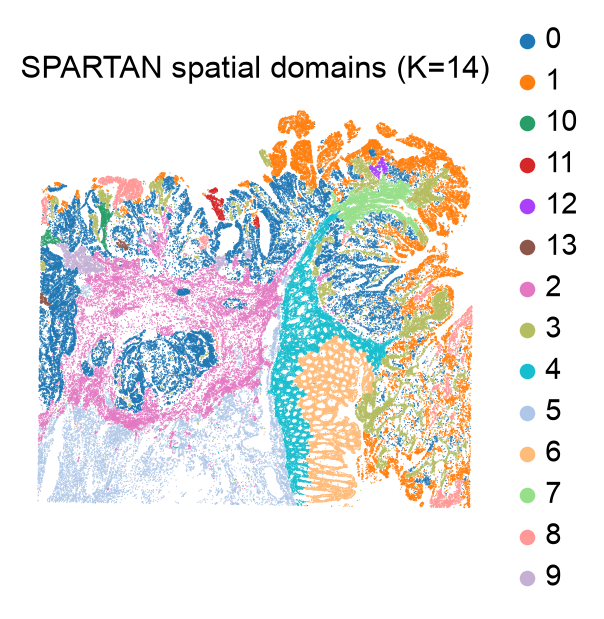

save_domain_labels_plot_and_metrics: 0.03 min; RSS 0.65 GB; delta +0.02 GB


,method,target_k,actual_k,resolution,seed,n_observations,n_hvgs,spatial_label_agreement,domain_size_cv,smallest_domain,largest_domain
0,SPARTAN,14,14,0.664844,1,131592,2000,0.987738,0.997473,280,32955


Saved: /Users/zhuzhengyang/Desktop/HDS_Dissertation/Human_Colon_Cancer_Visium_HD/spartan_benchmark_outputs/K14/human_colon_cancer_spartan_grid6_ring2_k14_labels.csv
Saved: /Users/zhuzhengyang/Desktop/HDS_Dissertation/Human_Colon_Cancer_Visium_HD/spartan_benchmark_outputs/K14/human_colon_cancer_spartan_grid6_ring2_k14_domain_counts.csv
Saved: /Users/zhuzhengyang/Desktop/HDS_Dissertation/Human_Colon_Cancer_Visium_HD/spartan_benchmark_outputs/K14/human_colon_cancer_spartan_grid6_ring2_k14_spatial_domains.png
time: 1.52 s (started: 2026-08-26 00:26:05 +01:00)


In [7]:
with record_step("save_domain_labels_plot_and_metrics"):
    prefix = f"human_colon_cancer_spartan_grid6_ring2_k{TARGET_K}"
    labels_path = OUT_DIR / f"{prefix}_labels.csv"
    counts_path = OUT_DIR / f"{prefix}_domain_counts.csv"
    plot_path = OUT_DIR / f"{prefix}_spatial_domains.png"

    labels = adata_spartan.obs[["spartan_domains"]].copy()
    labels.index.name = "observation_id"
    labels.to_csv(labels_path)
    spartan_counts.to_csv(counts_path, header=["n_observations"])

    domain_codes = adata_spartan.obs["spartan_domains"].cat.codes.to_numpy()
    spatial_graph = adata_spartan.obsp["spartan_spatial_graph"].tocsr()
    edge_rows, edge_cols = spatial_graph.nonzero()
    unique_edge_mask = edge_rows < edge_cols
    spatial_label_agreement = float(
        np.mean(domain_codes[edge_rows[unique_edge_mask]] == domain_codes[edge_cols[unique_edge_mask]])
    )

    domain_size_cv = float(spartan_counts.std(ddof=0) / spartan_counts.mean())
    benchmark_summary = {
        "method": "SPARTAN",
        "target_k": TARGET_K,
        "actual_k": actual_k,
        "resolution": FIXED_RESOLUTION,
        "seed": SEED,
        "n_observations": int(adata_spartan.n_obs),
        "n_hvgs": int(adata_spartan.n_vars),
        "spatial_label_agreement": spatial_label_agreement,
        "domain_size_cv": domain_size_cv,
        "smallest_domain": int(spartan_counts.min()),
        "largest_domain": int(spartan_counts.max()),
    }

    sc.pl.embedding(
        adata_spartan,
        basis="spatial",
        color="spartan_domains",
        size=1,
        title=f"SPARTAN spatial domains (K={actual_k})",
        show=False,
    )
    plt.gca().invert_yaxis()
    plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()

display(pd.DataFrame([benchmark_summary]))
print("Saved:", labels_path)
print("Saved:", counts_path)
print("Saved:", plot_path)

## 6. Compact biological validation using supervisor-specified markers

The heatmap reports standardized mean marker expression per inferred domain. It is a quick domain-marker comparison, not a substitute for pathology annotation.

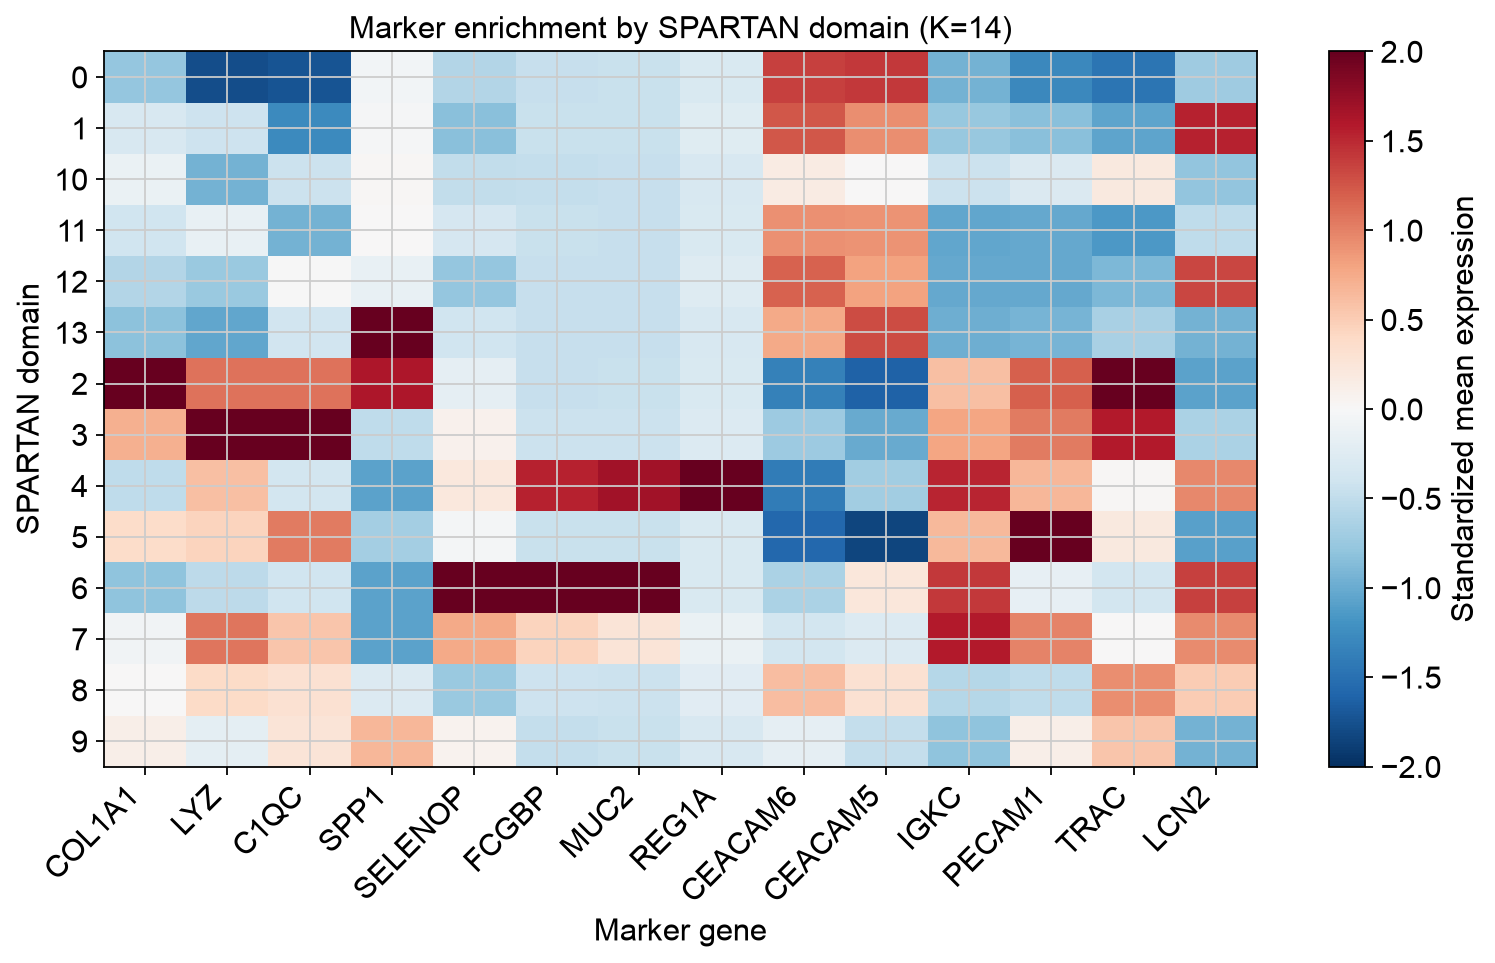

marker_domain_validation: 0.02 min; RSS 1.82 GB; delta +1.17 GB
Marker layer: normalized_no_log
Available markers: ['COL1A1', 'LYZ', 'C1QC', 'SPP1', 'SELENOP', 'FCGBP', 'MUC2', 'REG1A', 'CEACAM6', 'CEACAM5', 'IGKC', 'PECAM1', 'TRAC', 'LCN2']
Missing markers: ['REG2B']
Saved: /Users/zhuzhengyang/Desktop/HDS_Dissertation/Human_Colon_Cancer_Visium_HD/spartan_benchmark_outputs/K14/human_colon_cancer_spartan_grid6_ring2_k14_marker_means.csv
Saved: /Users/zhuzhengyang/Desktop/HDS_Dissertation/Human_Colon_Cancer_Visium_HD/spartan_benchmark_outputs/K14/human_colon_cancer_spartan_grid6_ring2_k14_marker_domain_heatmap.png
time: 1.22 s (started: 2026-08-26 00:26:07 +01:00)


In [8]:
MARKER_GENES = [
    "COL1A1",
    "LYZ",
    "C1QC",
    "SPP1",
    "SELENOP",
    "FCGBP",
    "MUC2",
    "REG1A",
    "REG2B",
    "CEACAM6",
    "CEACAM5",
    "IGKC",
    "PECAM1",
    "TRAC",
    "LCN2",
]

with record_step("marker_domain_validation"):
    available_markers = [gene for gene in MARKER_GENES if gene in adata_full.var_names]
    missing_markers = [gene for gene in MARKER_GENES if gene not in adata_full.var_names]
    marker_layer = "normalized_no_log" if "normalized_no_log" in adata_full.layers else None

    marker_adata = adata_full[adata_spartan.obs_names, available_markers]
    marker_matrix = marker_adata.layers[marker_layer] if marker_layer else marker_adata.X
    if sparse.issparse(marker_matrix):
        marker_matrix = marker_matrix.toarray()

    marker_frame = pd.DataFrame(
        np.asarray(marker_matrix, dtype=np.float32),
        index=marker_adata.obs_names,
        columns=available_markers,
    )
    marker_frame["spartan_domain"] = adata_spartan.obs["spartan_domains"].astype(str).to_numpy()
    marker_means = marker_frame.groupby("spartan_domain", sort=True)[available_markers].mean()
    marker_scale = marker_means.std(axis=0, ddof=0).replace(0, np.nan)
    marker_zscores = ((marker_means - marker_means.mean(axis=0)) / marker_scale).fillna(0)

    marker_means_path = OUT_DIR / f"{prefix}_marker_means.csv"
    marker_heatmap_path = OUT_DIR / f"{prefix}_marker_domain_heatmap.png"
    marker_means.to_csv(marker_means_path)

    fig_width = max(10, 0.65 * len(available_markers))
    fig_height = max(4, 0.45 * actual_k)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    image = ax.imshow(marker_zscores.to_numpy(), aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
    ax.set_xticks(np.arange(len(available_markers)))
    ax.set_xticklabels(available_markers, rotation=45, ha="right")
    ax.set_yticks(np.arange(actual_k))
    ax.set_yticklabels(marker_zscores.index)
    ax.set_xlabel("Marker gene")
    ax.set_ylabel("SPARTAN domain")
    ax.set_title(f"Marker enrichment by SPARTAN domain (K={actual_k})")
    fig.colorbar(image, ax=ax, label="Standardized mean expression")
    plt.tight_layout()
    plt.savefig(marker_heatmap_path, dpi=200, bbox_inches="tight")
    plt.show()

print("Marker layer:", marker_layer)
print("Available markers:", available_markers)
print("Missing markers:", missing_markers)
print("Saved:", marker_means_path)
print("Saved:", marker_heatmap_path)

## 7. Save benchmark timing and reproducibility metadata

In [9]:
timing_df = pd.DataFrame(step_times)
method_timing = timing_df.loc[timing_df["step"] == "spartan_fixed_k14"].iloc[0]

benchmark_summary.update(
    {
        "method_runtime_seconds": float(method_timing["seconds"]),
        "method_runtime_minutes": float(method_timing["minutes"]),
        "method_memory_start_gb": float(method_timing["memory_start_gb"]),
        "method_memory_end_gb": float(method_timing["memory_end_gb"]),
        "max_recorded_rss_gb": float(timing_df["memory_end_gb"].max()),
    }
)

timing_path = OUT_DIR / f"{prefix}_timing.csv"
benchmark_path = OUT_DIR / f"{prefix}_benchmark_summary.csv"
metadata_path = OUT_DIR / f"{prefix}_metadata.json"

timing_df.to_csv(timing_path, index=False)
pd.DataFrame([benchmark_summary]).to_csv(benchmark_path, index=False)

metadata = {
    "method": "SPARTAN",
    "input_sdata": str(SDATA_PATH),
    "table_key": TABLE_KEY,
    "parameters": SPARTAN_PARAMS,
    "target_k": TARGET_K,
    "actual_k": actual_k,
    "marker_layer": marker_layer,
    "available_markers": available_markers,
    "missing_markers": missing_markers,
    "python_version": sys.version,
    "platform": platform.platform(),
    "spartan_version": getattr(sp, "__version__", "unknown"),
    "scanpy_version": sc.__version__,
    "spatialdata_version": sd.__version__,
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

display(pd.DataFrame([benchmark_summary]))
display(timing_df)
print("Saved:", timing_path)
print("Saved:", benchmark_path)
print("Saved:", metadata_path)

/var/folders/7g/htgw64550j563bz1jw9wby_80000gn/T/ipykernel_1213/1028515166.py:34: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  "scanpy_version": sc.__version__,


,method,target_k,actual_k,resolution,seed,n_observations,n_hvgs,spatial_label_agreement,domain_size_cv,smallest_domain,largest_domain,method_runtime_seconds,method_runtime_minutes,method_memory_start_gb,method_memory_end_gb,max_recorded_rss_gb
0,SPARTAN,14,14,0.664844,1,131592,2000,0.987738,0.997473,280,32955,598.092653,9.968211,3.684925,0.613613,3.721355


,step,seconds,minutes,memory_start_gb,memory_end_gb,memory_delta_gb
0,load_full_table_and_select_2000_hvgs,26.671474,0.444525,0.380127,1.354542,0.974415
1,prepare_full_spartan_input,4.100884,0.068348,1.359879,3.721355,2.361477
2,spartan_fixed_k14,598.092653,9.968211,3.684925,0.613613,-3.071312
3,save_domain_labels_plot_and_metrics,1.512919,0.025215,0.628178,0.647041,0.018864
4,marker_domain_validation,1.220862,0.020348,0.649540,1.824417,1.174877


Saved: /Users/zhuzhengyang/Desktop/HDS_Dissertation/Human_Colon_Cancer_Visium_HD/spartan_benchmark_outputs/K14/human_colon_cancer_spartan_grid6_ring2_k14_timing.csv
Saved: /Users/zhuzhengyang/Desktop/HDS_Dissertation/Human_Colon_Cancer_Visium_HD/spartan_benchmark_outputs/K14/human_colon_cancer_spartan_grid6_ring2_k14_benchmark_summary.csv
Saved: /Users/zhuzhengyang/Desktop/HDS_Dissertation/Human_Colon_Cancer_Visium_HD/spartan_benchmark_outputs/K14/human_colon_cancer_spartan_grid6_ring2_k14_metadata.json
time: 12.9 ms (started: 2026-08-26 00:26:08 +01:00)
